In [29]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [30]:
class CrossCorrelationPlotter:
    """
    Visualization utilities for atmosphere-land cross-correlation diagnostics.

    Assumes 1-D variables indexed by land_point (or a flattened 1-D record axis),
    including:
      - correlation
      - distance_km
      - lat
      - lon

    Dataset attributes optionally used:
      - atm_var
      - land_var
      - atm_level_index
      - land_level_index
    """

    def __init__(self, nc_file):
        self.ds = xr.open_dataset(nc_file)

    # -------------------------------------------------
    # Internal helpers
    # -------------------------------------------------
    def _get_meta_title(self, include_levels=False):
        atm_var = self.ds.attrs.get("atm_var", "atm_var")
        land_var = self.ds.attrs.get("land_var", "land_var")

        if include_levels:
            atm_lev = self.ds.attrs.get("atm_level_index", "NA")
            land_lev = self.ds.attrs.get("land_level_index", "NA")
            return f"{atm_var}(lev={atm_lev}) vs {land_var}(lev={land_lev})"

        return f"{atm_var} vs {land_var}"

    def get_tag(self, time_tag=None):
        atm_var = self.ds.attrs.get("atm_var", "atm")
        land_var = self.ds.attrs.get("land_var", "land")
        atm_lev = self.ds.attrs.get("atm_level_index", "NA")
        land_lev = self.ds.attrs.get("land_level_index", "NA")

        tag = f"{atm_var}_lev{atm_lev}_vs_{land_var}_lev{land_lev}"
        if time_tag is not None:
            tag = f"{tag}_{time_tag}"
        return tag

    def _get_valid_arrays(self):
        lon = self.ds["lon"].values
        lat = self.ds["lat"].values
        corr = self.ds["correlation"].values

        mask = np.isfinite(lon) & np.isfinite(lat) & np.isfinite(corr)
        return lon[mask], lat[mask], corr[mask]

    def _get_valid_distance_corr(self, use_abs=False):
        dist = self.ds["distance_km"].values
        corr = self.ds["correlation"].values

        mask = np.isfinite(dist) & np.isfinite(corr)
        dist = dist[mask]
        corr = corr[mask]

        if use_abs:
            corr = np.abs(corr)

        return dist, corr

    def _subsample_arrays(self, *arrays, subsample=None, seed=42):
        if len(arrays) == 0:
            return arrays

        n = len(arrays[0])
        if not all(len(arr) == n for arr in arrays):
            raise ValueError("All input arrays must have the same length.")

        if subsample is None or subsample >= n:
            return arrays

        rng = np.random.default_rng(seed)
        idx = rng.choice(n, size=subsample, replace=False)
        return tuple(arr[idx] for arr in arrays)

    def _make_distance_bins(self, dist, bins):
        bin_edges = np.linspace(dist.min(), dist.max(), bins + 1)
        bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
        bin_ids = np.digitize(dist, bin_edges, right=False) - 1
        bin_ids[bin_ids == bins] = bins - 1
        return bin_edges, bin_centers, bin_ids

    def _finalize_figure(self, outfile=None, dpi=200, show=True):
        plt.tight_layout()
        if outfile is not None:
            plt.savefig(outfile, dpi=dpi, bbox_inches="tight")
            print(f"Saved figure: {outfile}")
        if show:
            plt.show()
        else:
            plt.close()

    # -------------------------------------------------
    # Basic scatter map with geographic context
    # -------------------------------------------------
    def plot_global_scatter(
        self,
        vmin=None,
        vmax=None,
        cmap="RdBu_r",
        point_size=1,
        subsample=None,
        seed=42,
        title=None,
        outfile=None,
        dpi=200,
        show=True,
        alpha=0.7,
        add_borders=True,
        add_land=False,
    ):
        lon, lat, corr = self._get_valid_arrays()
        lon, lat, corr = self._subsample_arrays(
            lon, lat, corr, subsample=subsample, seed=seed
        )

        # enforce symmetric color range around zero unless provided
        if vmin is None or vmax is None:
            vmax_auto = np.nanmax(np.abs(corr))
            vmin = -vmax_auto
            vmax = vmax_auto

        fig = plt.figure(figsize=(14, 5))
        ax = plt.axes(projection=ccrs.PlateCarree())

        sc = ax.scatter(
            lon,
            lat,
            c=corr,
            s=point_size,
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            alpha=alpha,
            transform=ccrs.PlateCarree(),
        )

        ax.set_global()
        ax.coastlines(linewidth=0.8)

        if add_borders:
            ax.add_feature(cfeature.BORDERS, linewidth=0.4)

        if add_land:
            ax.add_feature(cfeature.LAND, facecolor="lightgray", alpha=0.15)

        gl = ax.gridlines(
            draw_labels=True,
            linewidth=0.5,
            color="gray",
            alpha=0.5,
            linestyle="--",
        )
        gl.top_labels = False
        gl.right_labels = False
        gl.xlocator = mticker.FixedLocator(np.arange(-180, 181, 60))
        gl.ylocator = mticker.FixedLocator(np.arange(-90, 91, 30))

        cb = plt.colorbar(
            sc,
            ax=ax,
            orientation="horizontal",
            pad=0.06,
            fraction=0.05,
        )
        cb.set_label("Correlation")

        ax.set_title(title or self._get_meta_title())
        self._finalize_figure(outfile=outfile, dpi=dpi, show=show)

    # -------------------------------------------------
    # Histogram
    # -------------------------------------------------
    def plot_histogram(self, bins=50, outfile=None, dpi=200, show=True):
        corr = self.ds["correlation"].values
        corr = corr[np.isfinite(corr)]

        plt.figure(figsize=(6, 4))
        plt.hist(corr, bins=bins)
        plt.xlabel("Correlation")
        plt.ylabel("Count")
        plt.title("Distribution of cross-correlations")
        self._finalize_figure(outfile=outfile, dpi=dpi, show=show)

    # -------------------------------------------------
    # Correlation vs latitude
    # -------------------------------------------------
    def plot_latitudinal_mean(
        self,
        lat_bins=np.linspace(-90, 90, 37),
        outfile=None,
        dpi=200,
        show=True,
    ):
        corr = self.ds["correlation"]
        lat = self.ds["lat"]

        ds_lat = corr.groupby_bins(lat, bins=lat_bins).mean()
        lat_mid = [b.mid for b in ds_lat["lat_bins"].values]

        plt.figure(figsize=(6, 4))
        plt.plot(lat_mid, ds_lat.values)
        plt.xlabel("Latitude")
        plt.ylabel("Mean correlation")
        plt.title("Latitudinal mean correlation")
        plt.grid(True)
        self._finalize_figure(outfile=outfile, dpi=dpi, show=show)

    # -------------------------------------------------
    # Raw distance vs correlation scatter
    # -------------------------------------------------
    def plot_distance_relationship(
        self,
        subsample=None,
        seed=42,
        outfile=None,
        dpi=200,
        show=True,
    ):
        dist, corr = self._get_valid_distance_corr(use_abs=False)
        dist, corr = self._subsample_arrays(
            dist, corr, subsample=subsample, seed=seed
        )

        plt.figure(figsize=(6, 4))
        plt.scatter(dist, corr, s=1, alpha=0.3)
        plt.xlabel("Distance (km)")
        plt.ylabel("Correlation")
        plt.title("Correlation vs land-atmosphere separation distance")
        self._finalize_figure(outfile=outfile, dpi=dpi, show=show)

    # -------------------------------------------------
    # Distance-binned mean
    # -------------------------------------------------
    def plot_binned_distance_mean(
        self,
        bins=30,
        use_abs=False,
        show_counts=False,
        outfile=None,
        count_outfile=None,
        dpi=200,
        show=True,
    ):
        dist, corr = self._get_valid_distance_corr(use_abs=use_abs)
        bin_edges, bin_centers, bin_ids = self._make_distance_bins(dist, bins)

        mean_vals = np.full(bins, np.nan)
        counts = np.zeros(bins, dtype=int)

        for i in range(bins):
            m = bin_ids == i
            counts[i] = m.sum()
            if counts[i] > 0:
                mean_vals[i] = corr[m].mean()

        plt.figure(figsize=(6, 4))
        plt.plot(bin_centers, mean_vals, marker="o")
        plt.xlabel("Distance (km)")
        plt.ylabel("Mean |correlation|" if use_abs else "Mean correlation")
        plt.title("Distance-binned correlation")
        plt.grid(True)
        self._finalize_figure(outfile=outfile, dpi=dpi, show=show)

        if show_counts:
            plt.figure(figsize=(6, 3))
            plt.bar(bin_centers, counts, width=np.diff(bin_edges))
            plt.xlabel("Distance (km)")
            plt.ylabel("Count")
            plt.title("Counts per distance bin")
            self._finalize_figure(outfile=count_outfile, dpi=dpi, show=show)

    # -------------------------------------------------
    # Distance-binned percentiles
    # -------------------------------------------------
    def plot_binned_distance_percentiles(
        self,
        bins=30,
        use_abs=False,
        show_counts=False,
        outfile=None,
        count_outfile=None,
        dpi=200,
        show=True,
    ):
        dist, corr = self._get_valid_distance_corr(use_abs=use_abs)
        bin_edges, bin_centers, bin_ids = self._make_distance_bins(dist, bins)

        p10 = np.full(bins, np.nan)
        p50 = np.full(bins, np.nan)
        p90 = np.full(bins, np.nan)
        counts = np.zeros(bins, dtype=int)

        for i in range(bins):
            m = bin_ids == i
            counts[i] = m.sum()
            if counts[i] > 0:
                vals = corr[m]
                p10[i] = np.percentile(vals, 10)
                p50[i] = np.percentile(vals, 50)
                p90[i] = np.percentile(vals, 90)

        plt.figure(figsize=(6, 4))
        plt.fill_between(bin_centers, p10, p90, alpha=0.3, label="10–90%")
        plt.plot(bin_centers, p50, linewidth=2, label="Median")
        plt.xlabel("Distance (km)")
        plt.ylabel("|Correlation|" if use_abs else "Correlation")
        plt.title("Distance-binned correlation distribution")
        plt.grid(True)
        plt.legend()
        self._finalize_figure(outfile=outfile, dpi=dpi, show=show)

        if show_counts:
            plt.figure(figsize=(6, 3))
            plt.bar(bin_centers, counts, width=np.diff(bin_edges))
            plt.xlabel("Distance (km)")
            plt.ylabel("Count")
            plt.title("Counts per distance bin")
            self._finalize_figure(outfile=count_outfile, dpi=dpi, show=show)

    # -------------------------------------------------
    # Fraction exceeding |r| threshold vs distance
    # -------------------------------------------------
    def plot_distance_exceedance(
        self,
        bins=30,
        threshold=0.2,
        show_counts=False,
        outfile=None,
        count_outfile=None,
        dpi=200,
        show=True,
    ):
        dist, corr = self._get_valid_distance_corr(use_abs=True)
        bin_edges, bin_centers, bin_ids = self._make_distance_bins(dist, bins)

        frac = np.full(bins, np.nan)
        counts = np.zeros(bins, dtype=int)

        for i in range(bins):
            m = bin_ids == i
            counts[i] = m.sum()
            if counts[i] > 0:
                frac[i] = np.mean(corr[m] > threshold)

        plt.figure(figsize=(6, 4))
        plt.plot(bin_centers, frac, marker="o")
        plt.xlabel("Distance (km)")
        plt.ylabel(f"Fraction with |r| > {threshold}")
        plt.title("Correlation exceedance vs distance")
        plt.grid(True)
        self._finalize_figure(outfile=outfile, dpi=dpi, show=show)

        if show_counts:
            plt.figure(figsize=(6, 3))
            plt.bar(bin_centers, counts, width=np.diff(bin_edges))
            plt.xlabel("Distance (km)")
            plt.ylabel("Count")
            plt.title("Counts per distance bin")
            self._finalize_figure(outfile=count_outfile, dpi=dpi, show=show)

    # -------------------------------------------------
    # Convenience wrapper for old usage
    # -------------------------------------------------
    def save_scatter(
        self,
        outfile,
        subsample=30000,
        vmin=None,
        vmax=None,
        cmap="RdBu_r",
        seed=42,
        dpi=200,
    ):
        self.plot_global_scatter(
            vmin=vmin,
            vmax=vmax,
            cmap=cmap,
            point_size=2,
            subsample=subsample,
            seed=seed,
            title=self._get_meta_title(include_levels=True),
            outfile=outfile,
            dpi=dpi,
            show=False,
        )

    # -------------------------------------------------
    # Optional close method
    # -------------------------------------------------
    def close(self):
        self.ds.close()

Loading dataset:
/compyfs/zhan391/v3_dart_cda_scratch/DARTEN40_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy/archive/post/cross-corr/2011-12-18-00000/corr_T_lev79_vs_TSOISNO_levtot06_2011-12-18-00000.nc
Figure tag: T_lev79_vs_T_SOISNO_lev6_2011-12-18-00000
Saved figure: ./figures/corr_map_T_lev79_vs_T_SOISNO_lev6_2011-12-18-00000.png


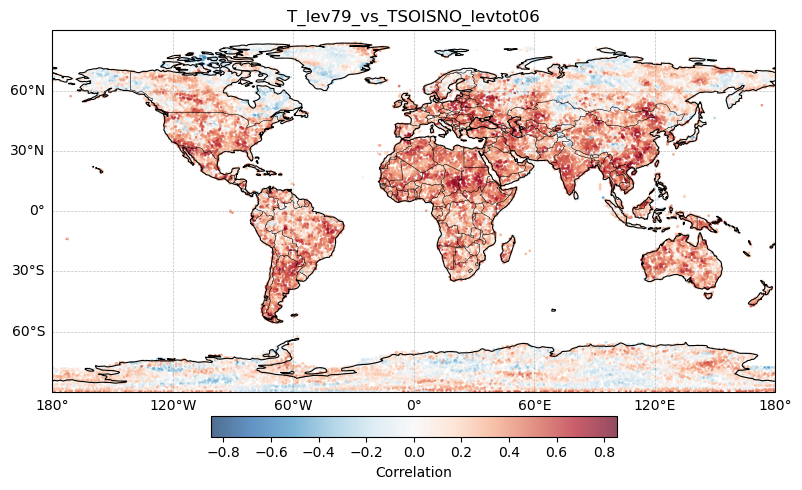

Saved figure: ./figures/corr_hist_T_lev79_vs_T_SOISNO_lev6_2011-12-18-00000.png


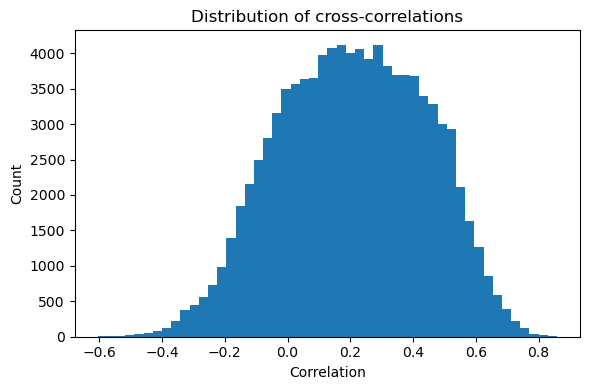

Saved figure: ./figures/corr_latmean_T_lev79_vs_T_SOISNO_lev6_2011-12-18-00000.png


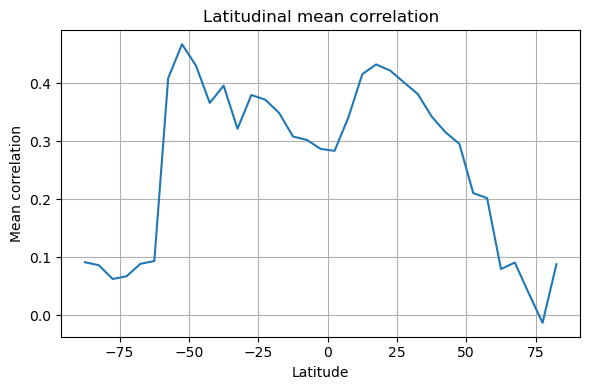

Saved figure: ./figures/dist_scatter_T_lev79_vs_T_SOISNO_lev6_2011-12-18-00000.png


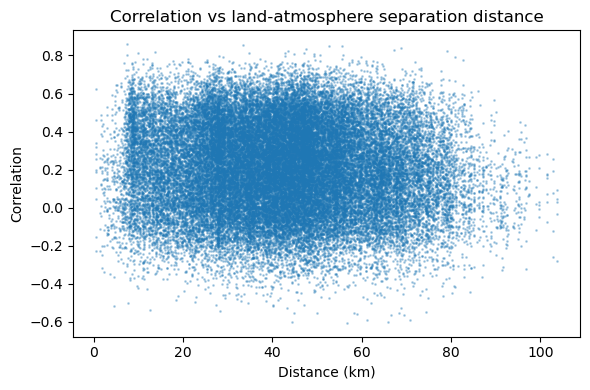

Saved figure: ./figures/dist_mean_T_lev79_vs_T_SOISNO_lev6_2011-12-18-00000.png


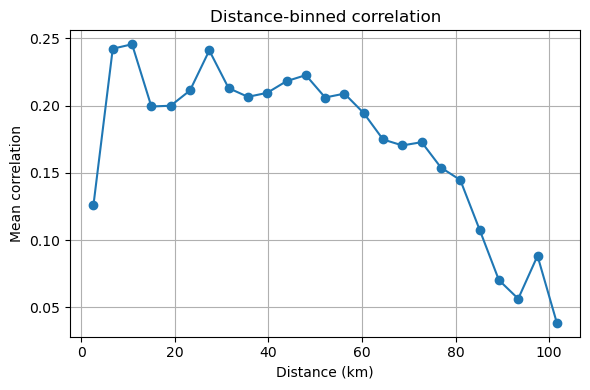

Saved figure: ./figures/dist_mean_abs_T_lev79_vs_T_SOISNO_lev6_2011-12-18-00000.png


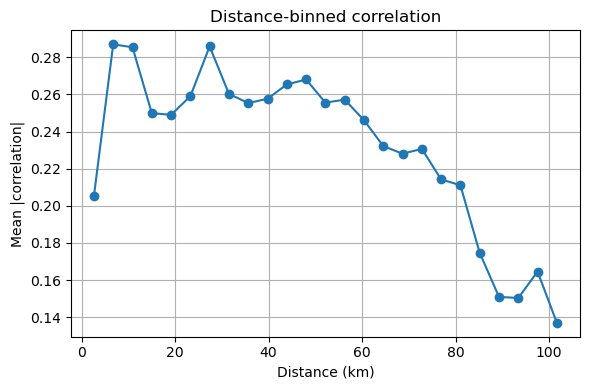

Saved figure: ./figures/dist_percentile_abs_T_lev79_vs_T_SOISNO_lev6_2011-12-18-00000.png


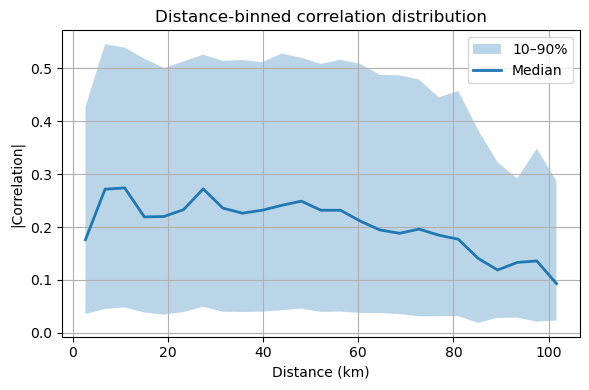

Saved figure: ./figures/dist_exceed_r0p2_T_lev79_vs_T_SOISNO_lev6_2011-12-18-00000.png


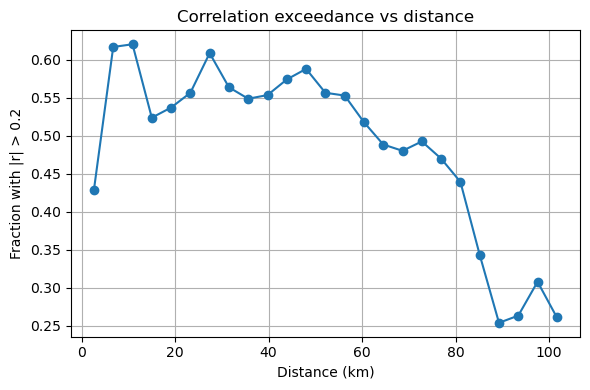

Diagnostics complete. Figures saved in:
./figures


In [50]:
if __name__ == "__main__":

    data_dir = "/compyfs/zhan391/v3_dart_cda_scratch"
    case_name = "DARTEN40_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy"
    sub_dir = "archive/post/cross-corr"
    time_tag = "2011-12-18-00000"

    base_dir = os.path.join(data_dir, case_name, sub_dir, time_tag)


    #var = "T_lev79_vs_TSOISNO_levtot00"
    #var = "T_lev79_vs_TSOISNO_levtot03"
    var = "T_lev79_vs_TSOISNO_levtot06"
    #var = "T_lev79_vs_TSOISNO_levtot09"
    #var = "T_lev79_vs_TSOISNO_levtot12"
    #var = "T_lev79_vs_TSOISNO_levtot15"
    #var = "T_lev79_vs_TSOISNO_levtot18"
    #var = "T_lev79_vs_TSOISNO_levtot19"
    #var = "T_lev00_vs_TSOISNO_levtot00"
    #var = "T_lev00_vs_TSOISNO_levtot03"
    #var = "T_lev00_vs_TSOISNO_levtot06"
    #var = "T_lev00_vs_TSOISNO_levtot09"
    #var = "T_lev00_vs_TSOISNO_levtot12"
    #var = "T_lev00_vs_TSOISNO_levtot15"
    #var = "T_lev00_vs_TSOISNO_levtot18"
    #var = "T_lev00_vs_TSOISNO_levtot19"
    
    fn = os.path.join(base_dir, f"corr_{var}_{time_tag}.nc")

    if not os.path.exists(fn):
        raise FileNotFoundError(f"Input file not found: {fn}")

    print(f"Loading dataset:\n{fn}")

    plotter = CrossCorrelationPlotter(fn)

    # -------------------------------------------------
    # Output directory and tag
    # -------------------------------------------------
    fig_dir = os.path.join("./", "figures")
    os.makedirs(fig_dir, exist_ok=True)

    tag = plotter.get_tag(time_tag=time_tag)
    print(f"Figure tag: {tag}")

    # -------------------------------------------------
    # Basic spatial diagnostics
    # -------------------------------------------------
    plotter.plot_global_scatter(
        title = var,
        subsample=30000,
        outfile=os.path.join(fig_dir, f"corr_map_{tag}.png"),
        show=True,
    )

    plotter.plot_histogram(
        outfile=os.path.join(fig_dir, f"corr_hist_{tag}.png"),
        show=True,
    )

    plotter.plot_latitudinal_mean(
        outfile=os.path.join(fig_dir, f"corr_latmean_{tag}.png"),
        show=True,
    )

    # -------------------------------------------------
    # Distance-correlation diagnostics
    # -------------------------------------------------
    plotter.plot_distance_relationship(
        subsample=50000,
        outfile=os.path.join(fig_dir, f"dist_scatter_{tag}.png"),
        show=True,
    )

    plotter.plot_binned_distance_mean(
        bins=25,
        use_abs=False,
        outfile=os.path.join(fig_dir, f"dist_mean_{tag}.png"),
        show=True,
    )

    plotter.plot_binned_distance_mean(
        bins=25,
        use_abs=True,
        outfile=os.path.join(fig_dir, f"dist_mean_abs_{tag}.png"),
        show=True,
    )

    plotter.plot_binned_distance_percentiles(
        bins=25,
        use_abs=True,
        outfile=os.path.join(fig_dir, f"dist_percentile_abs_{tag}.png"),
        show=True,
    )

    plotter.plot_distance_exceedance(
        bins=25,
        threshold=0.2,
        outfile=os.path.join(fig_dir, f"dist_exceed_r0p2_{tag}.png"),
        show=True,
    )

    plotter.close()

    print(f"Diagnostics complete. Figures saved in:\n{fig_dir}")